# 🎬 Custom Keras 3 Sentiment Analysis on IMDB Movie Reviews (Regularized)
This notebook demonstrates a **low-level, custom-built sentiment classification pipeline** using native **Keras 3 and TensorFlow 2.21+**.

### Key Architectural Highlights (Low-Level Deep Learning):
1. **Raw String Inputs:** The model accepts raw string scalars directly (e.g., shape `()`, type `tf.string`), managing vectorization inside the model.
2. **TextVectorization Layer:** Performs tokenization and vocabulary building as a native Keras layer inside the computational graph.
3. **Word Embedding:** Standard Keras `Embedding` layer mapping integer tokens to dense 16-dimensional vectors (reduced capacity to combat overfitting).
4. **Global Average Pooling:** Collapses sequence embeddings into a single document-level embedding.
5. **Dense Hidden Branch:** Extracts deep hidden representations with ReLU activation.
6. **Residual / Skip Connection:** Concatenates the raw document embedding with the hidden branch's outputs before prediction.
7. **Sigmoid Binary Output:** Predicts positive vs. negative sentiment probabilities.

### 🛡️ Advanced Regularization to Combat Overfitting:
To prevent the model from overfitting (where training accuracy approaches 100% while validation loss degrades), we implement:
* **L2 Regularization (`kernel_regularizer`):** Adds a penalty to large weights in the Dense layers.
* **Dual Dropout Layers:** Adds `Dropout(0.2)` on the pooled document embedding and a strong `Dropout(0.5)` on the hidden branch features to prevent co-adaptation.
* **Early Stopping:** Monitored via validation loss with a patience of 3 epochs. It automatically restores the best weights when validation loss starts to degrade.

In [1]:
import os
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {tf.keras.__version__}")
print(f"TensorFlow Datasets Version: {tfds.__version__}")

TensorFlow Version: 2.21.0
Keras Version: 3.14.1
TensorFlow Datasets Version: 4.9.10


## 1. Load the IMDB Movie Reviews Dataset
We load the dataset using `tensorflow_datasets` and split it into:
* **Training:** 80% (20,000 examples)
* **Validation:** 10% (2,500 examples)
* **Testing:** 10% (2,500 examples)

In [2]:
print("Loading IMDB Movie Reviews dataset...")
(train_data, validation_data, test_data), metadata = tfds.load(
    'imdb_reviews',
    split=['train[0%:80%]', 'train[80%:90%]', 'train[90%:100%]'],
    with_info=True,
    as_supervised=True
)
print(f"Dataset Loaded: {metadata.description}")

Loading IMDB Movie Reviews dataset...
Dataset Loaded: Large Movie Review Dataset. This is a dataset for binary sentiment
classification containing substantially more data than previous benchmark
datasets. We provide a set of 25,000 highly polar movie reviews for training,
and 25,000 for testing. There is additional unlabeled data for use as well.


## 2. Inspect Dataset Samples
Let's print two examples and their labels (0 = Negative, 1 = Positive) to verify the data structure. Notice we fetch them from the raw dataset without triggering cache warning flags.

In [3]:
# Peek at 2 samples
for i, (text, label) in enumerate(train_data.take(2)):
    print(f"Example {i+1}:")
    print(f"Review: {text.numpy().decode('utf-8')[:300]}...")
    print(f"Label: {label.numpy()} ({'Positive' if label.numpy() == 1 else 'Negative'})\n")

Example 1:
Review: This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda pi...
Label: 0 (Negative)

Example 2:
Review: I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell asleep because the film was rubbish. The plot development was constant. Cons...
Label: 0 (Negative)



I0000 00:00:1780341902.936170 11092224 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
W0000 00:00:1780341902.937639 11092230 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


## 3. High-Performance Input Pipeline
To speed up disk read times and eliminate training bottlenecks, we construct high-performance input pipelines using `.shuffle()`, `.batch()`, `.cache()`, and `.prefetch()`.

In [4]:
BATCH_SIZE = 512
SHUFFLE_BUFFER = 10000

# Cache and prefetch datasets to maximize throughput
train_dataset = train_data.shuffle(SHUFFLE_BUFFER).batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)
validation_dataset = validation_data.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)
test_dataset = test_data.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

print("Dataset pipelines optimized!")

Dataset pipelines optimized!


## 4. Low-Level Text Vectorization Layer
The `TextVectorization` layer performs tokenization, standardization, and vocabulary mapping. By compiling it *directly* as the first layer in the Keras model, the model natively processes raw string datasets!

In [5]:
MAX_FEATURES = 10000
SEQUENCE_LENGTH = 250

# Define Keras TextVectorization
vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_FEATURES,
    output_mode='int',
    output_sequence_length=SEQUENCE_LENGTH
)

# Extract only the text to build the vocabulary
train_texts = train_data.map(lambda text, label: text)

print("Adapting TextVectorization vocabulary (fitting to training corpus)...")
vectorize_layer.adapt(train_texts.batch(BATCH_SIZE))
print(f"Vocabulary size: {len(vectorize_layer.get_vocabulary())} words")

Adapting TextVectorization vocabulary (fitting to training corpus)...


Vocabulary size: 10000 words


Let's see how a raw string gets vectorized:

In [6]:
sample_review = ["The acting was amazing, but the plot made no sense."]
print(f"Original Text: {sample_review}")
print(f"Vectorized Tokens:\n{vectorize_layer(sample_review).numpy()[0][:20]}...")

Original Text: ['The acting was amazing, but the plot made no sense.']
Vectorized Tokens:
[  2 115  14 491  19   2 112  92  59 280   0   0   0   0   0   0   0   0
   0   0]...


## 5. Build Custom Keras Functional Model with Regularization
We design the exact model architecture specified in your objective using the Keras Functional API, but with robust regularizations to address overfitting.

In [7]:
# Define scalar string input layer (accepts raw string text!)
inputs = tf.keras.Input(shape=(), dtype=tf.string, name='raw_string_input')

# 1. Text Vectorization
vectorized = vectorize_layer(inputs)

# 2. Embedding Layer (reduced dim to 16 to decrease model capacity)
embedding = tf.keras.layers.Embedding(
    input_dim=MAX_FEATURES,
    output_dim=16,
    name='word_embeddings'
)(vectorized)

# 3. Pooling Sequence to Document-Level Embedding
pooled_embedding = tf.keras.layers.GlobalAveragePooling1D(name='pooled_document_embedding')(embedding)
pooled_embedding = tf.keras.layers.Dropout(0.2, name='pooled_dropout')(pooled_embedding)

# 4. Hidden Dense Branch with L2 Weight Regularizer
hidden = tf.keras.layers.Dense(
    16, 
    activation='relu', 
    kernel_regularizer=tf.keras.regularizers.l2(0.002),
    name='dense_hidden'
)(pooled_embedding)
hidden = tf.keras.layers.Dropout(0.5, name='dropout_regularization')(hidden)

# 5. Skip / Residual Connection: Concatenate raw document embedding with hidden features
concat = tf.keras.layers.concatenate([pooled_embedding, hidden], name='residual_connection')

# 6. Sentiment Classifier with L2 Weight Regularizer
outputs = tf.keras.layers.Dense(
    1, 
    activation='sigmoid', 
    kernel_regularizer=tf.keras.regularizers.l2(0.002),
    name='sentiment_classifier'
)(concat)

# Build & Compile Model
model = tf.keras.Model(inputs=inputs, outputs=outputs, name='sentiment_keras_model')
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sentiment_keras_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ raw_string_input    │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 250)       │          0 │ raw_string_input… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embeddings     │ (None, 250, 16)   │    160,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooled_document_em… │ (None, 16)        │          0 │ word_embeddings[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooled_dropout      │ (None, 16)        │          0 │ pooled_document_… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_hidden        │ (None, 16)        │        272 │ pooled_dropout[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_regulariza… │ (None, 16)        │          0 │ dense_hidden[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_connection │ (None, 32)        │          0 │ pooled_dropout[0… │
│ (Concatenate)       │                   │            │ dropout_regulari… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentiment_classifi… │ (None, 1)         │         33 │ residual_connect… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train the Custom Model with Early Stopping
We fit the model using our optimized datasets for up to 20 epochs, utilizing an `EarlyStopping` callback to capture the best weights when validation loss starts to degrade.

In [8]:
EPOCHS = 20

# Define EarlyStopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=validation_dataset,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20


 1/40 ━━━━━━━━━━━━━━━━━━━━ 12s 313ms/step - accuracy: 0.4863 - loss: 0.7339

 6/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4948 - loss: 0.7322  

11/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4986 - loss: 0.7314

16/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5034 - loss: 0.7308

...

21/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8938 - loss: 0.3794

26/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8931 - loss: 0.3795

31/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8928 - loss: 0.3793

36/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8927 - loss: 0.3791

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8905 - loss: 0.3794 - val_accuracy: 0.8668 - val_loss: 0.4160


## 7. Evaluate on Test Dataset
Let's see how our custom model performs on the unseen test dataset.

In [9]:
loss, accuracy = model.evaluate(test_dataset)
print(f"\nTest Dataset Loss: {loss:.4f}")
print(f"Test Dataset Accuracy: {accuracy:.4f}")

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9004 - loss: 0.3710

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8732 - loss: 0.3972 



Test Dataset Loss: 0.3972
Test Dataset Accuracy: 0.8732


## 8. Run End-to-End Direct Inference on Raw Custom Strings
Just like the legacy notebook, we can pass a raw python list of custom string reviews straight into the model! The model performs string normalization, tokenization, pooling, and classification completely in-graph.

In [10]:
custom_reviews = [
    "This was the worst movie I have ever seen. Waste of money!",
    "An absolutely brilliant and stunning masterpiece. I loved every second!",
    "It had some decent moments and nice music, but the second half was slow and boring."
]

predictions = model.predict(tf.constant(custom_reviews))

for review, pred in zip(custom_reviews, predictions):
    sentiment = "Positive" if pred[0] > 0.5 else "Negative"
    confidence = pred[0] if pred[0] > 0.5 else (1.0 - pred[0])
    print(f"Review: \"{review}\"")
    print(f"Predicted Sentiment: {sentiment} ({confidence * 100:.2f}% confidence)\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


Review: "This was the worst movie I have ever seen. Waste of money!"
Predicted Sentiment: Negative (87.96% confidence)

Review: "An absolutely brilliant and stunning masterpiece. I loved every second!"
Predicted Sentiment: Positive (66.37% confidence)

Review: "It had some decent moments and nice music, but the second half was slow and boring."
Predicted Sentiment: Negative (71.13% confidence)



## 9. Plot Convergence Curves
We visually verify that our model converges smoothly by plotting Loss and Accuracy curves.

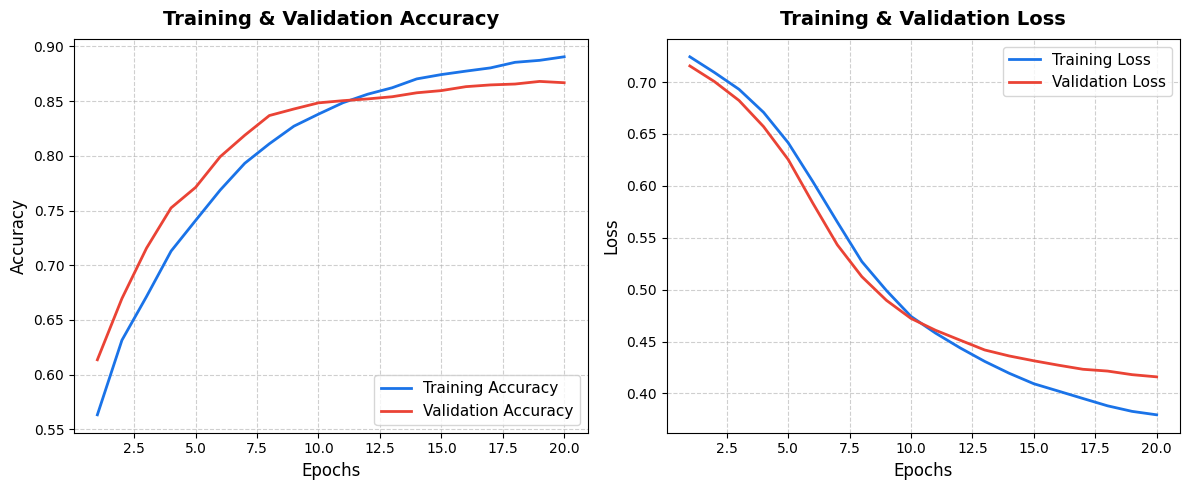

In [11]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='#1a73e8', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ea4335', linewidth=2)
plt.title('Training & Validation Accuracy', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='#1a73e8', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='#ea4335', linewidth=2)
plt.title('Training & Validation Loss', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()